In [1]:
import argparse, os, sys, glob, yaml, math, random
import cv2
import datetime, time
import numpy as np
from omegaconf import OmegaConf
from collections import OrderedDict
from tqdm import trange, tqdm
from einops import repeat
from einops import rearrange, repeat
from functools import partial
import torch
from pytorch_lightning import seed_everything

from funcs import load_model_checkpoint, load_video_batch, load_prompts, load_idx, load_traj, load_image_batch, get_filelist, save_videos, save_videos_with_bbox
from funcs import batch_ddim_inversion, batch_ddim_sampling_freetraj
from utils.utils import instantiate_from_config

import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'

/notebooks/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
name="smaps_test"

ckpt='../../checkpoints/base_512_v2/model.ckpt'
config='../../configs/inference_t2v_freetraj_512_v2.0.yaml'

res_dir=f"../../results_{name}"
ref_path="../../assets/reference_examples/car-roundabout-24.mp4"
prompt_ref_file="../../prompts/inversion/text_ref.txt"
prompt_gen_file="../../prompts/inversion/text.txt"
idx_file="../../prompts/inversion/idx.txt"

In [3]:
## step 1: model config
## -----------------------------------------------------------------
config = OmegaConf.load(config)
model_config = config.pop("model", OmegaConf.create())
model = instantiate_from_config(model_config)
model = model.cuda(0)
assert os.path.exists(ckpt), f"Error: checkpoint [{ckpt}] Not Found!"
model = load_model_checkpoint(model, ckpt)
model.eval()




max_size = 512

# load reference video
video_tmp = cv2.VideoCapture(ref_path)
init_frames = int(video_tmp.get(cv2.CAP_PROP_FRAME_COUNT))
init_height = int(video_tmp.get(cv2.CAP_PROP_FRAME_HEIGHT))
init_width = int(video_tmp.get(cv2.CAP_PROP_FRAME_WIDTH))
print(f"Initial shape: {init_frames} x {init_height} x {init_width}")

# fix frames number to avoid OOM
frames = min(model.temporal_length, init_frames)
print(f"Frame cut: {frames} x {init_height} x {init_width}")

assert (max_size % 64 == 0), "Error: size should be multiple of 64"
if init_height > init_width:
    height = max_size
    width = int((height / init_height) * init_width)
    print(f"Resizing: {frames} x {height} x {width}")
    width = ((width - 1) // 64 + 1) * 64
    print(f"Aligning: {frames} x {height} x {width}")
else:
    width = max_size
    height = int((width / init_width) * init_height)
    print(f"Resizing: {frames} x {height} x {width}")
    height = ((height - 1) // 64 + 1) * 64
    print(f"Aligning: {frames} x {height} x {width}")

video = load_video_batch([ref_path], 1, video_size=(height, width), video_frames=frames).to(model.device)
# B x C x F x H x W
# [-1, 1]
#write_video("test.mp4", ((video[0].permute(1, 2, 3, 0).cpu() + 1) / 2 * 255).to(dtype=torch.uint8), fps=args.savefps)
#save_videos(video.unsqueeze(1), os.path.join(args.savedir, 'ref'), filenames, fps=args.savefps)

AE working on z of shape (1, 4, 64, 64) = 16384 dimensions.


/notebooks/venv/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO:root:Loaded ViT-H-14 model config.


>>> model checkpoint loaded.
Initial shape: 24 x 480 x 864
Frame cut: 16 x 480 x 864
Resizing: 16 x 284 x 512
Aligning: 16 x 320 x 512


In [4]:
fps = 16


# video -> latents
latents = model.encode_first_stage_2DAE(video)
vs = video.shape
video = video.cpu()
#del video
torch.cuda.empty_cache()

assert os.path.exists(prompt_ref_file), "Error: reference video prompt file NOT Found!"
prompt_ref_list = load_prompts(prompt_ref_file)
# embed text
text_ref_emb = model.get_learned_conditioning(prompt_ref_list)
fps = torch.tensor([fps]*latents.shape[0]).to(model.device).long()
cond = {"c_crossattn": [text_ref_emb], "fps": fps}

In [5]:
ddim_steps = 50
ddim_eta = 0.0
unconditional_guidance_scale = 12.0

# inversion
out = batch_ddim_inversion(
    model, cond, latents, ddim_steps, ddim_eta, unconditional_guidance_scale, 
    log_every_t=1, return_self_attn=True
)

DDIM scale True
ddim device cuda:0


  0%|          | 0/50 [00:00<?, ?it/s]/notebooks/venv/lib/python3.11/site-packages/torch/utils/checkpoint.py:429: UserWarning: torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/notebooks/venv/lib/python3.11/site-packages/torch/utils/checkpoint.py:61: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
100%|██████████| 50/50 [05:45<00:00,  6.92s/it]


In [6]:
inversed, inters = out

In [7]:
from glob import glob

smaps = glob('/notebooks/smaps/*')

In [8]:
len(smaps)

135

In [12]:
#sorted(smaps)[:-18]

In [13]:
smaps_step1 = [
    '/notebooks/smaps/step1_layer17.pt',
    '/notebooks/smaps/step1_layer18.pt',
    '/notebooks/smaps/step1_layer19.pt',
    '/notebooks/smaps/step1_layer20.pt',
    '/notebooks/smaps/step1_layer21.pt',
    '/notebooks/smaps/step1_layer22.pt',
    '/notebooks/smaps/step1_layer23.pt',
    '/notebooks/smaps/step1_layer24.pt',
    '/notebooks/smaps/step1_layer25.pt',
]

100%|██████████| 9/9 [00:45<00:00,  5.08s/it]


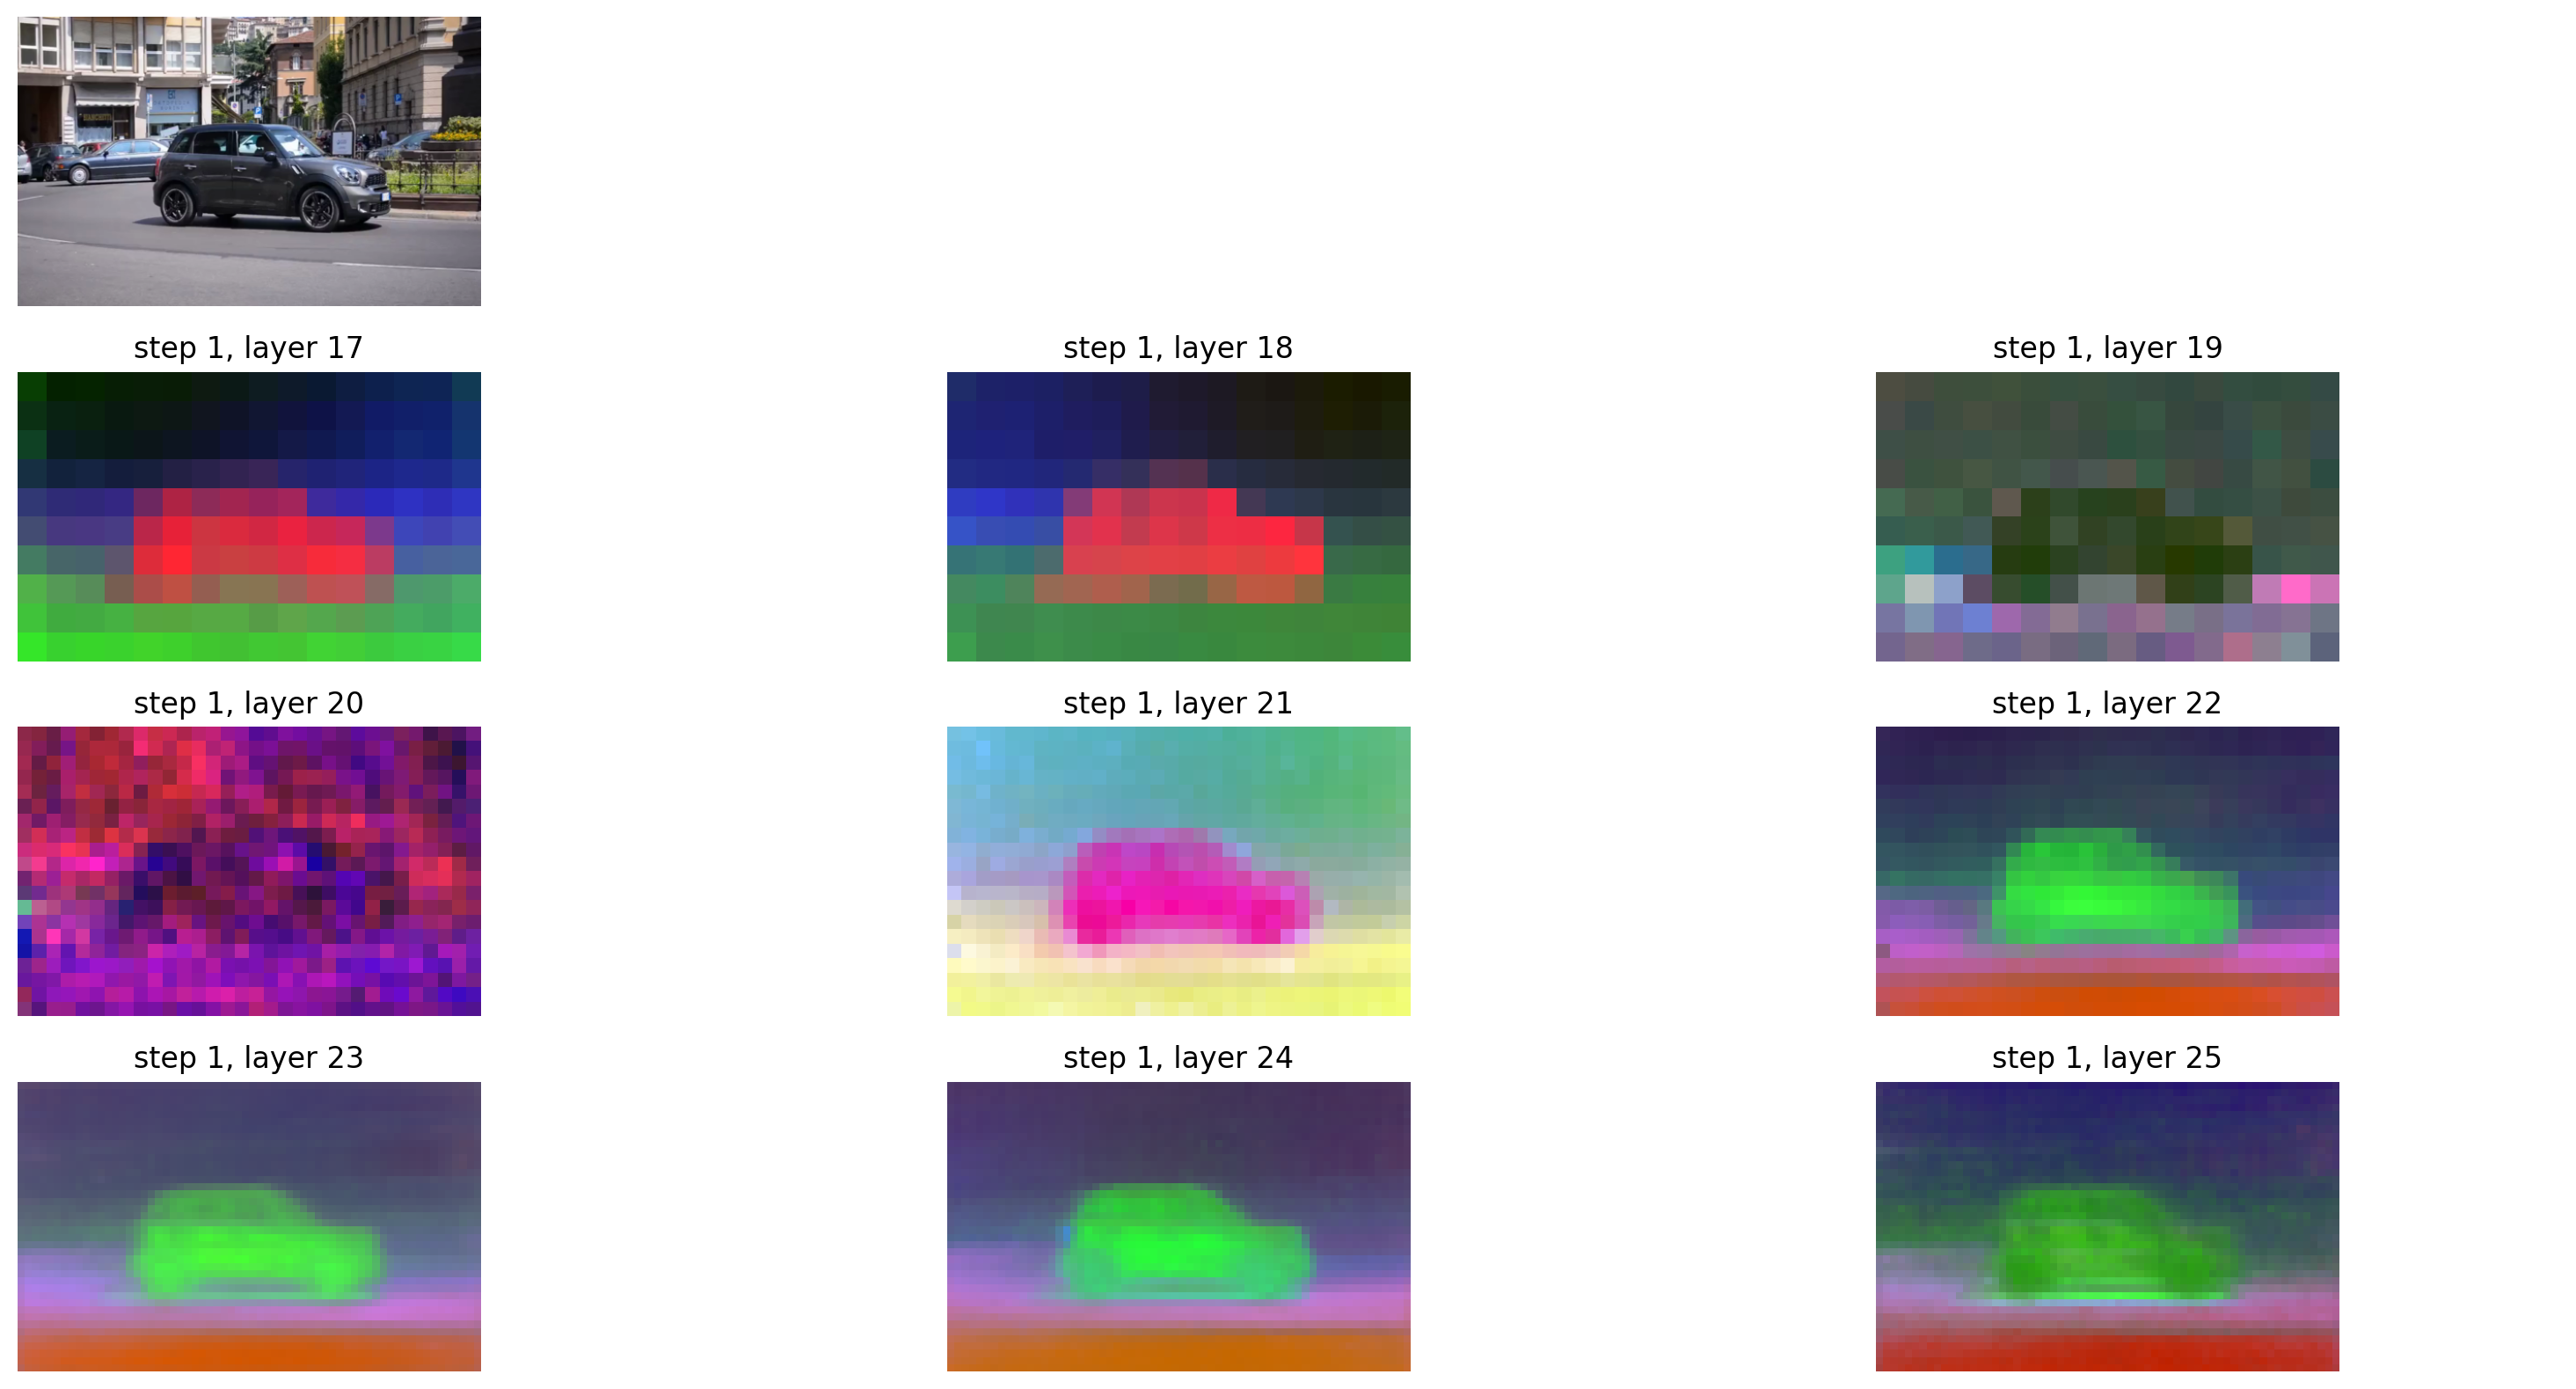

In [14]:
from torchvision.utils import make_grid
from sklearn.decomposition import PCA
from tqdm import tqdm

frame = 0
step = 1
#plt.title(prompt_ref_list[0])



fig, axs = plt.subplots(ncols=3, nrows=4, figsize=(16, 8))
vid = video[0, :, frame, ...].permute(1, 2, 0)
vid = ((vid + 1) / 2 * 255).to(dtype=torch.uint8)
axs[0, 0].imshow(vid)
for ax in axs[0, :]:
    ax.axis('off')


for i in tqdm(range(len(smaps_step1))):
    layer = smaps_step1[i][-5:-3]
    
    s = torch.load(smaps_step1[i])
    
    s_np = s.numpy()
    pca = PCA(n_components=3)
    s_pca = pca.fit_transform(s_np.reshape(-1, s_np.shape[-1]))
    s_pca = s_pca.reshape(s_np.shape[0], s_np.shape[1], -1)

    sz = int((s_pca.shape[1] / (latents.shape[-1] / latents.shape[-2])) ** (1/2))
    s_pca = s_pca.reshape(-1, frames, sz, int(sz * 1.6), 3)

    s_pca = s_pca.mean(axis=0)[frame]

    s_minmax = (s_pca - s_pca.min()) / (s_pca.max() - s_pca.min())

    axs[i//3 + 1, i%3].imshow(s_minmax)
    axs[i//3 + 1, i%3].axis('off')
    axs[i//3 + 1, i%3].set_title(f'step {step}, layer {layer}')
    
plt.tight_layout()

In [16]:
smaps_selected = [
    (9, '/notebooks/smaps/step1_layer18.pt'),
    (12, '/notebooks/smaps/step1_layer21.pt'),
    (15, '/notebooks/smaps/step1_layer24.pt'),
]

100%|██████████| 3/3 [00:11<00:00,  3.68s/it]


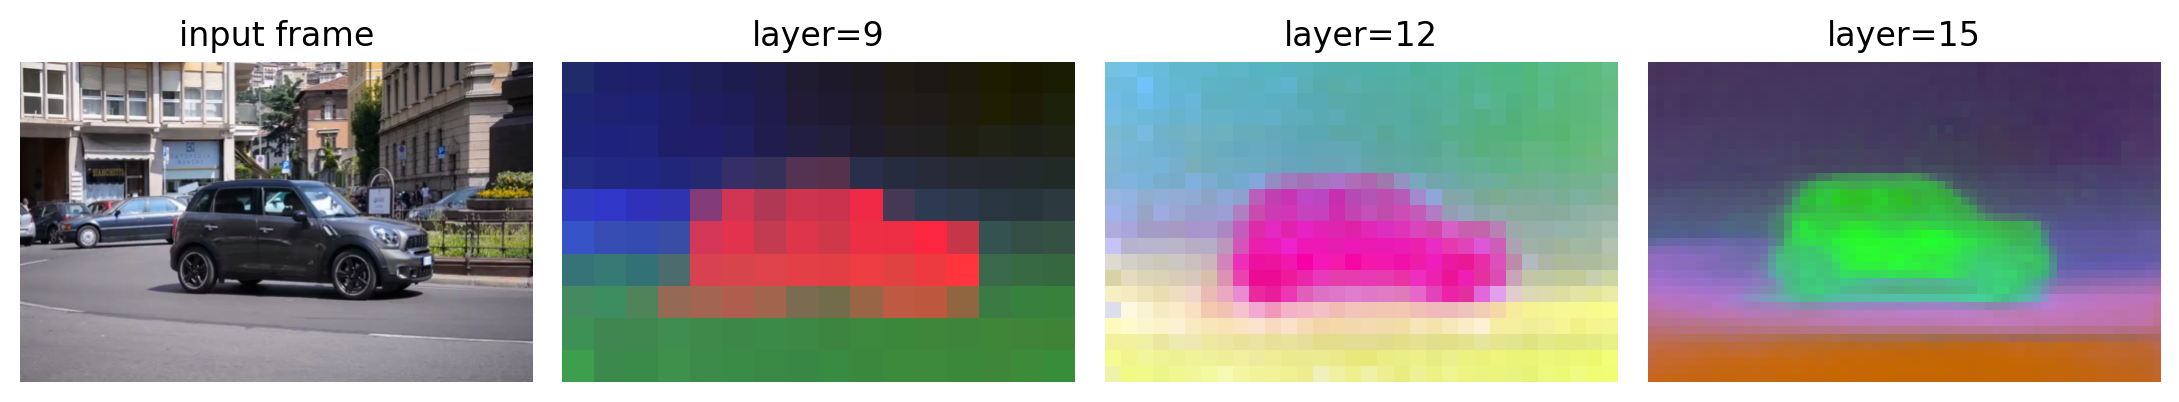

In [20]:
from torchvision.utils import make_grid
from sklearn.decomposition import PCA
from tqdm import tqdm

frame = 0
#plt.title(prompt_ref_list[0])



fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(11, 5))
vid = video[0, :, frame, ...].permute(1, 2, 0)
vid = ((vid + 1) / 2 * 255).to(dtype=torch.uint8)
axs[0].imshow(vid)
axs[0].set_title('input frame')
axs[0].axis('off')

for i, (layer, path) in tqdm(enumerate(smaps_selected), total=len(smaps_selected)):    
    s = torch.load(path)
    
    s_np = s.numpy()
    pca = PCA(n_components=3)
    s_pca = pca.fit_transform(s_np.reshape(-1, s_np.shape[-1]))
    s_pca = s_pca.reshape(s_np.shape[0], s_np.shape[1], -1)

    sz = int((s_pca.shape[1] / (latents.shape[-1] / latents.shape[-2])) ** (1/2))
    s_pca = s_pca.reshape(-1, frames, sz, int(sz * 1.6), 3)

    s_pca = s_pca.mean(axis=0)[frame]

    s_minmax = (s_pca - s_pca.min()) / (s_pca.max() - s_pca.min())

    axs[i+1].imshow(s_minmax)
    axs[i+1].axis('off')
    axs[i+1].set_title(f'layer={layer}')
    
plt.tight_layout()